# Physics-Informed Neural Networks (PINNs)

Physics-informed neural networks (PINNs) integrate physical laws, typically expressed as differential equations, directly into the neural network's training process. By penalizing the model when it violates these laws, PINNs generate highly accurate, physically consistent predictions—even when working with very sparse real-world data.

PINNs are a class of physics-informed machine learning methods that seamlessly integrate physics knowledge with data. Often, PINNs get compared with purely data-driven methods and traditional numerical methods for solving problems involving PDEs and ODEs. 

Unlike purely data-driven approaches, which learn mathematical relationships solely from input and output data, PINNs:

* Use prior physics knowledge.
* Make more accurate predictions outside of the training data set.
* Are more effective with limited or noisy training data.

PINNs differ from traditional neural networks in their ability to incorporate a priori domain knowledge of the problem in the form of differential equations. This additional information enables PINNs to make more accurate predictions outside of the given measurement data. Furthermore, the additional physics knowledge regularizes the predicted solution in the presence of noisy measurement data, enabling PINNs to learn the true underlying signal rather than overfitting the noisy data. 

---

## Example: Solving a 1D Heat Equation with a PINN

To demonstrate how PINNs work, we'll solve a simple boundary value problem governed by the one-dimensional steady-state heat equation:

$$
\frac{\partial u}{\partial t}
=
\alpha
\frac{\partial^2 u}{\partial x^2}
$$

where:

- $u(x)$ represents the temperature distribution along a rod.
- $x$ is the position along the rod.
- The rod extends from $x=0$ to $x=1$.

### Boundary Conditions

Assume the rod has fixed temperatures at both ends:

$$
u(0)=0,
u(1)=1
$$
The analytical solution is simply:



Our goal is to train a neural network to discover this solution without directly providing the function itself.

### PINN Architecture

The neural network takes a spatial coordinate $x$ as input and predicts the temperature $u(x)$:

Epoch     0 | Total: 2.290984e-01 | Physics: 6.401317e-02 | Boundary: 1.650853e-01
Epoch   500 | Total: 8.859196e-05 | Physics: 8.821227e-05 | Boundary: 3.796862e-07
Epoch  1000 | Total: 6.192709e-06 | Physics: 6.188367e-06 | Boundary: 4.341407e-09
Epoch  1500 | Total: 4.307875e-06 | Physics: 4.306803e-06 | Boundary: 1.071782e-09
Epoch  2000 | Total: 3.014701e-06 | Physics: 3.014098e-06 | Boundary: 6.022322e-10
Epoch  2500 | Total: 2.040892e-06 | Physics: 2.039252e-06 | Boundary: 1.640030e-09
Epoch  3000 | Total: 1.415880e-06 | Physics: 1.405995e-06 | Boundary: 9.884969e-09
Epoch  3500 | Total: 9.841243e-07 | Physics: 9.783513e-07 | Boundary: 5.772972e-09
Epoch  4000 | Total: 6.821205e-07 | Physics: 6.819613e-07 | Boundary: 1.591685e-10
Epoch  4500 | Total: 4.797505e-07 | Physics: 4.796837e-07 | Boundary: 6.678660e-11


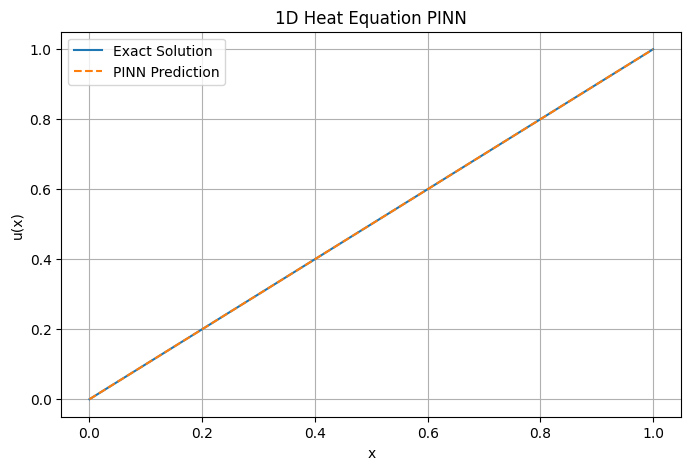

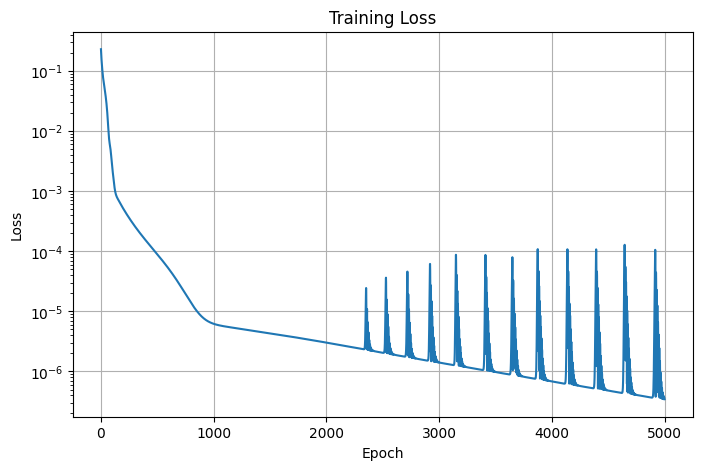

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Domain points
N_f = 1000  # collocation points

x_f = np.random.rand(N_f, 1)
x_f = tf.convert_to_tensor(x_f, dtype=tf.float32)

# Boundary conditions
x_bc = tf.constant([[0.0],
                    [1.0]], dtype=tf.float32)

u_bc = tf.constant([[0.0],
                    [1.0]], dtype=tf.float32)


# Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(20, activation='tanh'),
    tf.keras.layers.Dense(1)
])

# PDE Residual
def pde_residual(x):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)

        with tf.GradientTape() as tape1:
            tape1.watch(x)
            u = model(x)

        u_x = tape1.gradient(u, x)

    u_xx = tape2.gradient(u_x, x)

    del tape2

    return u_xx

# Loss Function
def loss_function():

    # Physics loss
    f = pde_residual(x_f)
    physics_loss = tf.reduce_mean(tf.square(f))

    # Boundary loss
    u_pred_bc = model(x_bc)
    boundary_loss = tf.reduce_mean(
        tf.square(u_pred_bc - u_bc)
    )

    total_loss = physics_loss + boundary_loss

    return total_loss, physics_loss, boundary_loss

# Training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

epochs = 5000

loss_history = []

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        total_loss, physics_loss, boundary_loss = loss_function()

    grads = tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    loss_history.append(total_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.numpy():.6e} | "
            f"Physics: {physics_loss.numpy():.6e} | "
            f"Boundary: {boundary_loss.numpy():.6e}"
        )

# Prediction
x_test = np.linspace(0, 1, 200).reshape(-1, 1)

u_pred = model(
    tf.convert_to_tensor(
        x_test,
        dtype=tf.float32
    )
).numpy()

# Analytical solution
u_exact = x_test

# Plot Solution
plt.figure(figsize=(8,5))

plt.plot(
    x_test,
    u_exact,
    label="Exact Solution"
)

plt.plot(
    x_test,
    u_pred,
    "--",
    label="PINN Prediction"
)

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("1D Heat Equation PINN")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))

plt.semilogy(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()

In [ ]:
# YOUR TURN! Implement a PINN to solve the simple harmonic oscillator numerically.

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Physical parameters
m = 1.0      # mass
c = 4.0      # damping coefficient  
k = 400.0    # spring constant

# Derived parameters
delta = c / (2 * m)                # damping ratio
omega_0 = np.sqrt(k / m)           # natural frequency
omega = np.sqrt(omega_0**2 - delta**2) # damped frequency

print(f"Physical parameters:")
print(f"  δ = {delta:.2f} (damping ratio)")
print(f"  ω₀ = {omega_0:.2f} (natural frequency)")
print(f"  ω = {omega:.2f} (damped frequency)")
print(f"  Underdamped: {delta < omega_0}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def oscillator(d, w0, x):
    """Analytical solution to the 1D underdamped harmonic oscillator problem."""
    assert d < w0
    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d / w)
    A = 1 / (2 * np.cos(phi))
    cos = np.cos(phi + w * x)
    exp = np.exp(-d * x)
    y = exp * 2 * A * cos
    return y

def create_spring_oscillator_animation_inline():
    d = 2  # damping coefficient
    w0 = 20  # natural frequency
    
    # Animation variables
    totalTime = 1.0  # Time domain [0, 1]
    dt = 0.0075
    t_array = np.arange(0, totalTime, dt)
    y_array = oscillator(d, w0, t_array)

    # Scaling factors
    scale = 1.0
    centerY = 0.0

    # Compute y_min and y_max from the displacement data
    y_min = np.min(y_array * scale + centerY)
    y_max = np.max(y_array * scale + centerY)

    # Create figure and axes
    fig, (ax_trace, ax_spring) = plt.subplots(1, 2, figsize=(12, 4))
    plt.tight_layout(pad=3.0)

    # Plot the displacement curve on ax_trace
    ax_trace.plot(t_array, y_array * scale + centerY, color='gray')
    trace_point, = ax_trace.plot([], [], 'bo', markersize=8)
    ax_trace.set_xlim(0, totalTime)
    ax_trace.set_ylim(-1.1, 1.1)  
    ax_trace.set_xlabel('Time (s)')
    ax_trace.set_ylabel('Displacement')
    ax_trace.set_title('Displacement vs. Time')

    # Set up the mass-spring system on ax_spring
    ax_spring.set_xlim(-1, 1)
    ax_spring.set_ylim(-1.1, 1.1)  
    ax_spring.axis('off')
    ax_spring.set_title('Mass-Spring System')

    # Draw the fixed block at equilibrium position (y=0)
    ax_spring.plot([-0.2, 0.2], [1.0, 1.0], 'k-', linewidth=4)

    # Initialize the mass and spring
    mass, = ax_spring.plot([], [], 'bo', markersize=20)
    spring_line, = ax_spring.plot([], [], 'k-', linewidth=1.5)

    def get_spring(y_start, y_end, coils=10, points_per_coil=15):
        length = y_end - y_start
        t = np.linspace(0, 1, coils * points_per_coil)
        x = 0.06 * np.sin(2 * np.pi * coils * t)
        y = y_start + length * t
        return x, y

    def update(frame):
        t = t_array[frame % len(t_array)]
        y = oscillator(d, w0, t) * scale + centerY

        # Update trace point
        trace_point.set_data([t], [y])

        # Update mass position
        mass.set_data([0], [y])

        # Update spring
        x_spring, y_spring = get_spring(1.0, y)  # Starting from y=1.0 (fixed point)
        spring_line.set_data(x_spring, y_spring)

        return trace_point, mass, spring_line

    ani = FuncAnimation(fig, update, frames=len(t_array), interval=20, blit=True)

    plt.close(fig)

# Call the function to display the animation
create_spring_oscillator_animation_inline()

In [ ]:
# Generate sparse training data
n_data = 10  # Only 10 data points!

def exact_solution(t):
    """Analytical solution to the damped harmonic oscillator"""
    return np.exp(-delta * t) * (np.cos(omega * t) + (delta/omega) * np.sin(omega * t))

# Get solution
t_data = np.linspace(0, 0.3607, n_data)
u_data = exact_solution(t_data)

# Exact solution
t_exact = np.linspace(0, 1, 500)
u_exact = exact_solution(t_exact)


# Add some noise to make it realistic
noise_level = 0.02
u_data_noisy = u_data + noise_level * np.random.normal(0, 1, len(u_data))

# Visualize the sparse data
plt.figure(figsize=(10, 6))
plt.plot(t_exact, u_exact, 'k--', linewidth=2, alpha=0.7, label='True solution')
plt.scatter(t_data, u_data_noisy, color='red', s=100, zorder=5, label=f'Training data ({n_data} points)')
plt.xlabel('Time t')
plt.ylabel('Displacement u(t)')
plt.title('The Challenge: Reconstruct the Full Solution from Sparse Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training data: {n_data} points with noise level {noise_level}")
print("Challenge: Can a neural network reconstruct the full solution?")

In [ ]:
def compute_derivatives_demo():
    """Demonstrate automatic differentiation"""
    # Create a simple test case: u(t) = sin(t)
    t = torch.tensor([0.5], requires_grad=True)  # Enable gradient computation
    u = torch.sin(t)  # u = sin(t)
    
    print("Function: u(t) = sin(t)")
    print(f"At t = {t.item():.2f}:")
    print(f"  u = {u.item():.6f}")
    
    # First derivative: du/dt
    du_dt = torch.autograd.grad(u, t, create_graph=True)[0]
    print(f"  du/dt = {du_dt.item():.6f} (exact: cos({t.item():.2f}) = {np.cos(t.item()):.6f})")
    
    # Second derivative: d²u/dt²
    d2u_dt2 = torch.autograd.grad(du_dt, t, create_graph=True)[0]
    print(f"  d²u/dt² = {d2u_dt2.item():.6f} (exact: -sin({t.item():.2f}) = {-np.sin(t.item()):.6f})")
    
    print("✅ Automatic differentiation gives exact derivatives!")

compute_derivatives_demo()